Data source: https://github.com/AslanDing/SFBench.git

| Type | Stations | Unit | Description |
|-----|-----|-----|-----|
| Water | 993 | Feet | Water Stage |
| Groundwater | 582 | Feet | Stage of Groundwater |
| Rainfall | 349 | Inches | Rainfall |
| Pump | 99 | RPM | Rotational Speed |
| Gate | 429 | Feet | Opening Level |

In [1]:
from pathlib import Path
import json
import pandas as pd

root = Path("../../../Data/SF2Bench/extracted_data/Processed_hour/WATER/S_7")

print("Root exists:", root.exists())
print("Root resolved:", root.resolve())

# find all location json files
loc_jsons = list(root.rglob("*loc_info.json"))

print("Total loc_info files:", len(loc_jsons))

records = []

for json_file in loc_jsons:
    station = json_file.parent.name      # e.g. 3A-11_B
    group = json_file.parent.parent.name # S_7

    with open(json_file, "r") as f:
        data = json.load(f)

    records.append({
        "station": station,
        "group": group,
        "Latitude_raw": data.get("Latitude"),
        "Longitude_raw": data.get("Longitude"),
        "X_COORD": data.get("X COORD"),
        "Y_COORD": data.get("Y COORD"),
    })

water_df = pd.DataFrame(records)

print("water_df shape:", water_df.shape)
water_df.head()

Root exists: True
Root resolved: C:\Users\hai\OneDrive - Georgia Institute of Technology\Data\SF2Bench\extracted_data\Processed_hour\WATER\S_7
Total loc_info files: 716
water_df shape: (716, 6)


,station,group,Latitude_raw,Longitude_raw,X_COORD,Y_COORD
0,3A-11_B,S_7,261305.301,804438.212,740111.320,685058.455
1,3A-NE,S_7,261608.280,803652.140,782502.110,703639.313
2,3A-NW,S_7,261559.340,804646.200,728425.794,702608.643
3,3A-SW_B,S_7,255923.334,805010.225,709980.134,602022.486
4,3A-S_B,S_7,260455.534,804129.551,757409.480,635647.592


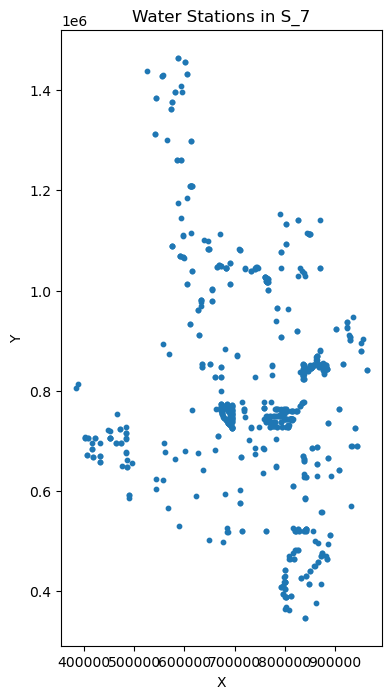

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

water_gdf = gpd.GeoDataFrame(
    water_df.copy(),
    geometry=gpd.points_from_xy(water_df["X_COORD"], water_df["Y_COORD"]),
    crs="EPSG:2236"   # set this later once you know the CRS
)

fig, ax = plt.subplots(figsize=(8, 8))
water_gdf.plot(ax=ax, markersize=10)
ax.set_title("Water Stations in S_7")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

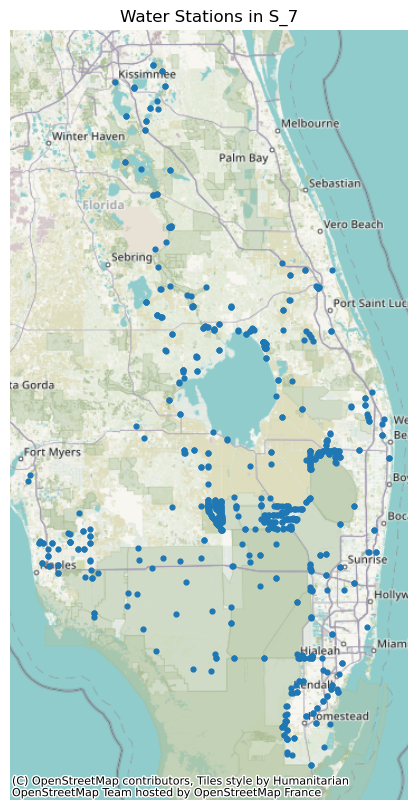

In [15]:
import contextily as cx

water_gdf_web = water_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
water_gdf_web.plot(ax=ax, markersize=12)
cx.add_basemap(ax)
ax.set_title("Water Stations in S_7")
ax.set_axis_off()
plt.show()

In [16]:
water_ll = water_gdf.to_crs("EPSG:4326")

In [17]:
from shapely.geometry import Point
import geopandas as gpd

fort_myers = gpd.GeoDataFrame(
    geometry=[Point(-81.8723, 26.6406)],
    crs="EPSG:4326"
)

In [18]:
water_m = water_ll.to_crs(3857)
fort_m = fort_myers.to_crs(3857)

water_m["distance"] = water_m.distance(fort_m.geometry.iloc[0])

In [19]:
nearest = water_m.nsmallest(2, "distance")

nearest[["station", "group", "distance"]]

,station,group,distance
157,6MI.PR_H,S_7,10268.377660
38,6MI.DR.H_H,S_7,12395.327365


In [5]:
Fort_myers_6MIPRH = pd.read_csv("../../../Data/SF2Bench/extracted_data/Processed_hour/WATER/S_7/6MI.PR_H/6MI.PR_H.csv")
Fort_myers_6MIPRH.head()

,TIMESTAMP,VALUE,CONFIDENCE,INTERPOLATED_VALUE
0,2020-01-01 00:00:00,14.41,7,14.41
1,2020-01-01 01:00:00,14.41,6,14.41
2,2020-01-01 02:00:00,14.41,6,14.41
3,2020-01-01 03:00:00,14.41,6,14.41
4,2020-01-01 04:00:00,14.41,6,14.41


In [6]:
Fort_myers_6MIPRH['VALUE'].describe()

count    35064.000000
mean        13.993794
std          1.329874
min          0.000000
25%         14.030000
50%         14.370000
75%         14.681667
max         16.960000
Name: VALUE, dtype: float64

In [7]:
Fort_myers_6MIDRHH = pd.read_csv("../../../Data/SF2Bench/extracted_data/Processed_hour/WATER/S_7/6MI.DR.H_H/6MI.DR.H_H.csv")
Fort_myers_6MIDRHH.head()

,TIMESTAMP,VALUE,CONFIDENCE,INTERPOLATED_VALUE
0,1/1/20 0:00,13.720000,7,13.720000
1,1/1/20 1:00,13.720000,6,13.720000
2,1/1/20 2:00,13.720000,6,13.720000
3,1/1/20 3:00,13.716667,6,13.716667
4,1/1/20 4:00,13.710000,6,13.710000


In [8]:
Fort_myers_6MIDRHH['VALUE'].describe()

count    35064.000000
mean        13.188371
std          1.476563
min          0.000000
25%         13.210000
50%         13.690000
75%         13.880000
max         15.770000
Name: VALUE, dtype: float64